In [135]:
# =============================================================
# CELLULE 1 — IMPORTS ET CONFIGURATION
# =============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Seed pour la reproductibilité
SEED = 42
np.random.seed(SEED)

# Style des graphiques
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"]      = 12

# Options d'affichage pandas
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows",    100)
pd.set_option("display.precision",   2)

print("✓ Environnement configuré avec succès.")

✓ Environnement configuré avec succès.


In [136]:
# =============================================================
# CELLULE 2 — CHARGEMENT DU DATASET BRUT
# =============================================================

df = pd.read_csv("../data/raw/diabetic_data.csv",
                 na_values="?",
                 low_memory=False)

# --- Copie de travail ---
# On ne touche jamais df (données brutes)
# Toutes les modifications se font sur df_clean
df_clean = df.copy()

# --- Dimensions avant nettoyage ---
print("=" * 45)
print("DATASET BRUT — AVANT NETTOYAGE")
print("=" * 45)
print(f"  Lignes   : {df.shape[0]:,}")
print(f"  Colonnes : {df.shape[1]}")
print("=" * 45)

DATASET BRUT — AVANT NETTOYAGE
  Lignes   : 101,766
  Colonnes : 50


In [137]:
# =============================================================
# CELLULE 3 — SUPPRESSION DES COLONNES INUTILES
# =============================================================

colonnes_a_supprimer = {
    "weight"       : "97% de valeurs manquantes",
    "payer_code"   : "40% de valeurs manquantes, peu utile",
    "encounter_id" : "Identifiant technique, pas médical",
}

print("Colonnes supprimées :")
for col, raison in colonnes_a_supprimer.items():
    print(f"  - {col:<20} → {raison}")

# Suppression sur df_clean uniquement
df_clean = df_clean.drop(columns=list(colonnes_a_supprimer.keys()))

print(f"\nColonnes avant : {df.shape[1]}")
print(f"Colonnes après : {df_clean.shape[1]}")

Colonnes supprimées :
  - weight               → 97% de valeurs manquantes
  - payer_code           → 40% de valeurs manquantes, peu utile
  - encounter_id         → Identifiant technique, pas médical

Colonnes avant : 50
Colonnes après : 47


In [138]:
# =============================================================
# CELLULE 4 — EXCLUSION DES PATIENTS DÉCÉDÉS
# =============================================================

# La colonne discharge_disposition_id indique
# ce qui s'est passé à la sortie du patient.
# Certains codes correspondent à un décès :
# 11 = décédé à l'hôpital
# 19 = décédé à domicile (soins palliatifs)
# 20 = décédé en soins palliatifs
# 21 = décédé (autre)
# Un patient décédé ne peut PAS être réadmis
# → ces lignes doivent être exclues

codes_deces = [11, 19, 20, 21]

# Nombre de patients décédés
nb_deces = df_clean[
    df_clean["discharge_disposition_id"].isin(codes_deces)
].shape[0]

print(f"Patients décédés détectés : {nb_deces:,}")

# Suppression
df_clean = df_clean[
    ~df_clean["discharge_disposition_id"].isin(codes_deces)
]

# Vérification
print(f"\nLignes avant : {df.shape[0]:,}")
print(f"Lignes après : {df_clean.shape[0]:,}")
print(f"Lignes supprimées : {df.shape[0] - df_clean.shape[0]:,}")

Patients décédés détectés : 1,652

Lignes avant : 101,766
Lignes après : 100,114
Lignes supprimées : 1,652


In [139]:
# =============================================================
# CELLULE 5 — REMPLACEMENT NaN PAR "Non mesuré"
# =============================================================

# Ces colonnes ont beaucoup de valeurs manquantes
# mais sont médicalement importantes
# → On ne les supprime pas
# → On crée une catégorie "Non mesuré" qui dit
#    au modèle : "cette mesure n'a pas été faite"

colonnes_non_mesure = [
    "max_glu_serum",
    "A1Cresult",
    "medical_specialty"
]

for col in colonnes_non_mesure:
    nb_avant = df_clean[col].isnull().sum()
    df_clean[col] = df_clean[col].fillna("Non mesuré")
    nb_apres = df_clean[col].isnull().sum()
    print(f"  {col:<25} "
          f"NaN avant : {nb_avant:>6,} → "
          f"NaN après : {nb_apres}")

print("\n✓ Remplacement terminé.")

  max_glu_serum             NaN avant : 94,890 → NaN après : 0
  A1Cresult                 NaN avant : 83,238 → NaN après : 0
  medical_specialty         NaN avant : 49,129 → NaN après : 0

✓ Remplacement terminé.


In [140]:
# =============================================================
# CELLULE 6 — IMPUTATION DES VARIABLES À FAIBLE MANQUANT
# =============================================================

# Ces colonnes ont très peu de valeurs manquantes
# → On les remplace par la valeur la plus fréquente
#   (mode) pour race
# → On les remplace par "Unknown" pour les diagnostics
#   car on ne peut pas deviner un code médical

# --- Race → valeur la plus fréquente ---
mode_race = df_clean["race"].mode()[0]
nb_avant  = df_clean["race"].isnull().sum()
df_clean["race"] = df_clean["race"].fillna(mode_race)
print(f"  race → imputé par '{mode_race}' "
      f"({nb_avant} valeurs remplacées)")

# --- Diagnostics → "Unknown" ---
colonnes_diag = ["diag_1", "diag_2", "diag_3"]

for col in colonnes_diag:
    nb_avant = df_clean[col].isnull().sum()
    df_clean[col] = df_clean[col].fillna("Unknown")
    print(f"  {col:<10} → imputé par 'Unknown' "
          f"({nb_avant} valeurs remplacées)")

# --- Vérification ---
print("\nValeurs manquantes restantes :")
manquantes = df_clean.isnull().sum()
manquantes = manquantes[manquantes > 0]

if len(manquantes) == 0:
    print("  ✓ Aucune valeur manquante restante !")
else:
    print(manquantes)

  race → imputé par 'Caucasian' (2239 valeurs remplacées)
  diag_1     → imputé par 'Unknown' (21 valeurs remplacées)
  diag_2     → imputé par 'Unknown' (358 valeurs remplacées)
  diag_3     → imputé par 'Unknown' (1421 valeurs remplacées)

Valeurs manquantes restantes :
  ✓ Aucune valeur manquante restante !


In [141]:
# =============================================================
# CELLULE 7 — CONSTRUCTION DE LA VARIABLE CIBLE BINAIRE
# =============================================================

# La variable originale "readmitted" a 3 valeurs :
# "<30" = réadmis en moins de 30 jours → 1 (cas positif)
# ">30" = réadmis après 30 jours       → 0 (cas négatif)
# "NO"  = jamais réadmis               → 0 (cas négatif)

# Création de la variable binaire
df_clean["readmitted_binary"] = (
    df_clean["readmitted"] == "<30"
).astype(int)

# Suppression de la colonne originale
# (on n'en a plus besoin)
df_clean = df_clean.drop(columns=["readmitted"])

# --- Vérification ---
counts = df_clean["readmitted_binary"].value_counts()
total  = len(df_clean)

print("=" * 45)
print("VARIABLE CIBLE BINAIRE")
print("=" * 45)
print(f"  Classe 0 (non réadmis) : "
      f"{counts[0]:>6,}  ({counts[0]/total*100:.1f}%)")
print(f"  Classe 1 (réadmis <30) : "
      f"{counts[1]:>6,}  ({counts[1]/total*100:.1f}%)")
print("=" * 45)

VARIABLE CIBLE BINAIRE
  Classe 0 (non réadmis) : 88,757  (88.7%)
  Classe 1 (réadmis <30) : 11,357  (11.3%)


In [142]:
# =============================================================
# CELLULE 8 — GESTION DES PATIENTS MULTI-SÉJOURS
# =============================================================

# Problème : un même patient peut apparaître plusieurs fois
# Si patient_nbr = 12345 est dans le train ET dans le test
# → le modèle a déjà "vu" ce patient → résultats biaisés
# C'est ce qu'on appelle le DATA LEAKAGE

# --- Avant ---
nb_avant          = len(df_clean)
nb_patients_avant = df_clean["patient_nbr"].nunique()

print("=" * 45)
print("AVANT")
print("=" * 45)
print(f"  Séjours  : {nb_avant:,}")
print(f"  Patients : {nb_patients_avant:,}")

# --- Garder uniquement le premier séjour ---
# sort_values → trie par patient et par index
# drop_duplicates → garde la première occurrence
df_clean = df_clean.sort_values("patient_nbr") \
                   .drop_duplicates(subset="patient_nbr",
                                    keep="first") \
                   .reset_index(drop=True)

# --- Après ---
nb_apres          = len(df_clean)
nb_patients_apres = df_clean["patient_nbr"].nunique()

print("\n" + "=" * 45)
print("APRÈS")
print("=" * 45)
print(f"  Séjours  : {nb_apres:,}")
print(f"  Patients : {nb_patients_apres:,}")
print(f"\n  Lignes supprimées : {nb_avant - nb_apres:,}")

# --- Suppression de patient_nbr ---
# On n'en a plus besoin maintenant
df_clean = df_clean.drop(columns=["patient_nbr"])
print("\n✓ patient_nbr supprimé.")

AVANT
  Séjours  : 100,114
  Patients : 70,439

APRÈS
  Séjours  : 70,439
  Patients : 70,439

  Lignes supprimées : 29,675

✓ patient_nbr supprimé.


In [143]:
# Ajoute cette cellule pour comprendre la perte
print("Patients décédés exclus :")
codes_deces = [11, 19, 20, 21]
nb_deces = df[
    df["discharge_disposition_id"].isin(codes_deces)
].shape[0]
print(f"  {nb_deces:,}")

print("\nSéjours supprimés (multi-séjours) :")
nb_multi = df.shape[0] - df.drop_duplicates(
    subset="patient_nbr").shape[0]
print(f"  {nb_multi:,}")

Patients décédés exclus :
  1,652

Séjours supprimés (multi-séjours) :
  30,248


In [144]:
# Vérification des types
print(df_clean.dtypes)

race                          str
gender                        str
age                           str
admission_type_id           int64
discharge_disposition_id    int64
admission_source_id         int64
time_in_hospital            int64
medical_specialty             str
num_lab_procedures          int64
num_procedures              int64
num_medications             int64
number_outpatient           int64
number_emergency            int64
number_inpatient            int64
diag_1                        str
diag_2                        str
diag_3                        str
number_diagnoses            int64
max_glu_serum                 str
A1Cresult                     str
metformin                     str
repaglinide                   str
nateglinide                   str
chlorpropamide                str
glimepiride                   str
acetohexamide                 str
glipizide                     str
glyburide                     str
tolbutamide                   str
pioglitazone  

In [145]:
# Vérification de gender
print(df_clean["gender"].value_counts())

gender
Female             37468
Male               32968
Unknown/Invalid        3
Name: count, dtype: int64


In [146]:
# Vérification discharge_disposition_id
print(df_clean["discharge_disposition_id"].value_counts().head(10))

discharge_disposition_id
1     43987
3      9097
6      8402
18     2484
2      1510
22     1345
5       881
25      653
4       558
7       415
Name: count, dtype: int64


In [147]:
# =============================================================
# CELLULE 9 — gender
# =============================================================

# --- Suppression des 3 lignes gender "Unknown/Invalid" ---
nb_avant = len(df_clean)
df_clean = df_clean[df_clean["gender"] != "Unknown/Invalid"]
nb_apres = len(df_clean)

print(f"Lignes supprimées (gender inconnu) : "
      f"{nb_avant - nb_apres}")
print(f"Lignes restantes : {nb_apres:,}")

# --- Vérification finale ---
print("\nDistribution gender :")
print(df_clean["gender"].value_counts())

Lignes supprimées (gender inconnu) : 3
Lignes restantes : 70,436

Distribution gender :
gender
Female    37468
Male      32968
Name: count, dtype: int64


In [148]:
# =============================================================
# CELLULE 10 — VÉRIFICATION FINALE
# =============================================================

print("=" * 50)
print("BILAN DU NETTOYAGE")
print("=" * 50)

# --- Dimensions ---
print(f"\n  Lignes avant   : {df.shape[0]:,}")
print(f"  Lignes après   : {df_clean.shape[0]:,}")
print(f"  Lignes perdues : {df.shape[0] - df_clean.shape[0]:,}")

print(f"\n  Colonnes avant : {df.shape[1]}")
print(f"  Colonnes après : {df_clean.shape[1]}")

# --- Valeurs manquantes ---
print("\n" + "=" * 50)
print("VALEURS MANQUANTES RESTANTES")
print("=" * 50)
manquantes = df_clean.isnull().sum()
manquantes = manquantes[manquantes > 0]

if len(manquantes) == 0:
    print("  ✓ Aucune valeur manquante !")
else:
    for col, val in manquantes.items():
        print(f"  {col:<30} {val}")

# --- Distribution de la cible ---
print("\n" + "=" * 50)
print("DISTRIBUTION DE LA VARIABLE CIBLE")
print("=" * 50)
counts = df_clean["readmitted_binary"].value_counts()
total  = len(df_clean)
print(f"  Classe 0 (non réadmis) : "
      f"{counts[0]:>6,}  ({counts[0]/total*100:.1f}%)")
print(f"  Classe 1 (réadmis <30) : "
      f"{counts[1]:>6,}  ({counts[1]/total*100:.1f}%)")

# --- Aperçu final ---
print("\n" + "=" * 50)
print("APERÇU DU DATASET NETTOYÉ")
print("=" * 50)
display(df_clean.head())

BILAN DU NETTOYAGE

  Lignes avant   : 101,766
  Lignes après   : 70,436
  Lignes perdues : 31,330

  Colonnes avant : 50
  Colonnes après : 46

VALEURS MANQUANTES RESTANTES
  ✓ Aucune valeur manquante !

DISTRIBUTION DE LA VARIABLE CIBLE
  Classe 0 (non réadmis) : 65,310  (92.7%)
  Classe 1 (réadmis <30) :  5,126  (7.3%)

APERÇU DU DATASET NETTOYÉ


,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted_binary
0,Caucasian,Female,[50-60),2,1,1,8,Cardiology,77,6,33,0,0,0,401,997,560,8,Non mesuré,Non mesuré,Steady,No,No,No,No,No,No,Down,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,1
1,Caucasian,Female,[50-60),3,1,1,2,Surgery-Neuro,49,1,11,0,0,0,722,305,250,3,Non mesuré,Non mesuré,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,0
2,Caucasian,Female,[80-90),1,3,7,4,InternalMedicine,68,2,23,0,0,0,820,493,E880,9,Non mesuré,>7,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,0
3,Caucasian,Female,[80-90),1,1,7,3,InternalMedicine,46,0,20,0,0,0,274,427,416,9,Non mesuré,>8,Steady,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Ch,Yes,0
4,AfricanAmerican,Female,[30-40),1,1,7,5,InternalMedicine,49,0,5,0,0,0,590,220,250,3,Non mesuré,Non mesuré,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,0


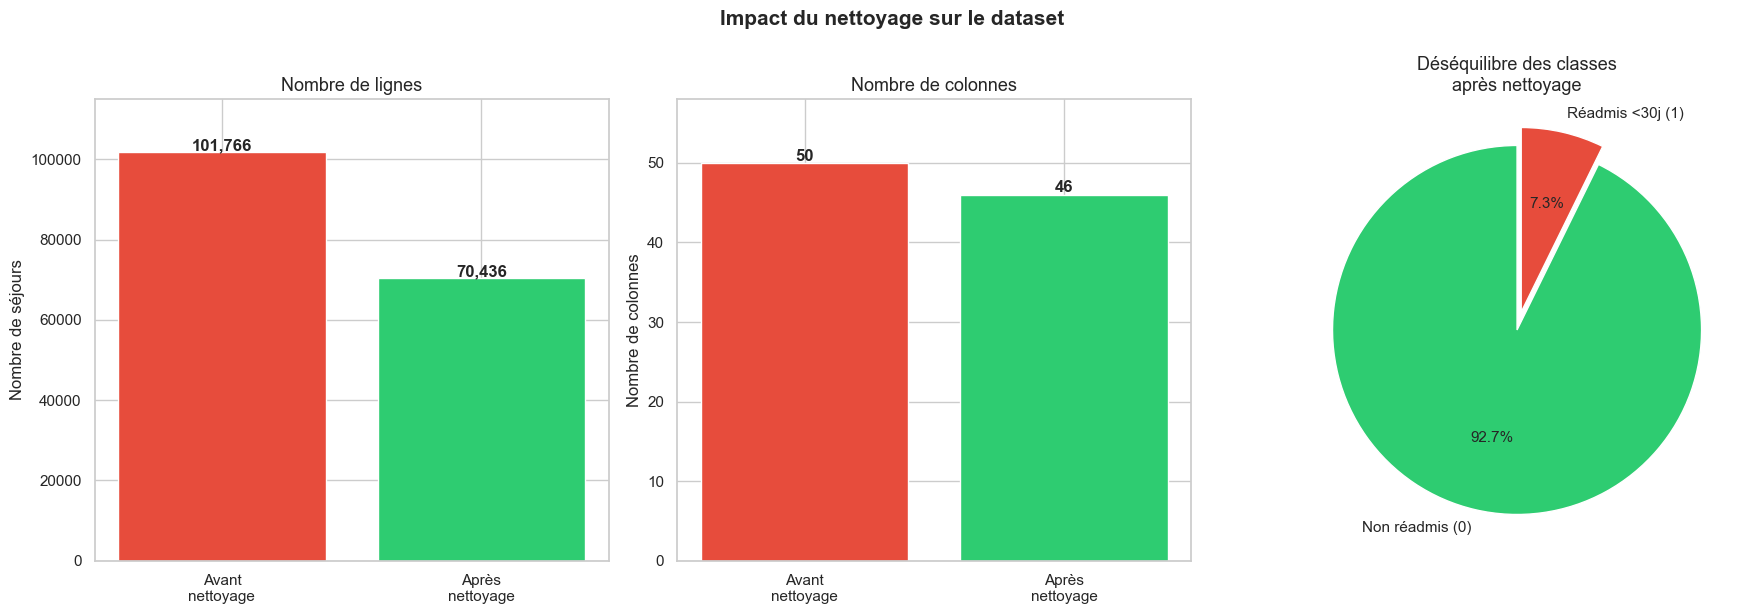

In [149]:
# =============================================================
# CELLULE — VISUALISATION DE L'IMPACT DU NETTOYAGE
# =============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- Graphique 1 : Lignes avant / après ---
labels  = ["Avant\nnettoyage", "Après\nnettoyage"]
valeurs = [df.shape[0], df_clean.shape[0]]
couleurs = ["#E74C3C", "#2ECC71"]

bars = axes[0].bar(labels, valeurs,
                   color=couleurs, edgecolor="white")
for bar, val in zip(bars, valeurs):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 500,
                 f"{val:,}", ha="center",
                 fontsize=12, fontweight="bold")

axes[0].set_title("Nombre de lignes", fontsize=13)
axes[0].set_ylabel("Nombre de séjours")
axes[0].set_ylim(0, 115000)

# --- Graphique 2 : Colonnes avant / après ---
valeurs_col = [df.shape[1], df_clean.shape[1]]

bars = axes[1].bar(labels, valeurs_col,
                   color=couleurs, edgecolor="white")
for bar, val in zip(bars, valeurs_col):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.3,
                 f"{val}", ha="center",
                 fontsize=12, fontweight="bold")

axes[1].set_title("Nombre de colonnes", fontsize=13)
axes[1].set_ylabel("Nombre de colonnes")
axes[1].set_ylim(0, 58)

# --- Graphique 3 : Déséquilibre des classes ---
counts = df_clean["readmitted_binary"].value_counts()
total  = len(df_clean)

axes[2].pie([counts[0], counts[1]],
            labels=["Non réadmis (0)", "Réadmis <30j (1)"],
            colors=["#2ECC71", "#E74C3C"],
            autopct="%1.1f%%",
            explode=(0, 0.1),
            startangle=90,
            textprops={"fontsize": 11})

axes[2].set_title("Déséquilibre des classes\naprès nettoyage",
                  fontsize=13)

plt.suptitle("Impact du nettoyage sur le dataset",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [150]:
# =============================================================
# CELLULE 10 — SAUVEGARDE DU DATASET NETTOYÉ
# =============================================================

# On sauvegarde dans data/processed/
# Ce fichier sera utilisé par tous les notebooks suivants
# (feature engineering, modélisation, etc.)

chemin = "../data/processed/data_clean.csv"

df_clean.to_csv(chemin, index=False)

print(f"✓ Dataset nettoyé sauvegardé avec succès.")
print(f"  Chemin  : {chemin}")
print(f"  Lignes  : {df_clean.shape[0]:,}")
print(f"  Colonnes: {df_clean.shape[1]}")

✓ Dataset nettoyé sauvegardé avec succès.
  Chemin  : ../data/processed/data_clean.csv
  Lignes  : 70,436
  Colonnes: 46


## Conclusions du nettoyage

### 1. Colonnes supprimées
| Colonne | Raison |
|---|---|
| `weight` | 97% de valeurs manquantes |
| `payer_code` | 40% manquant, peu utile médicalement |
| `encounter_id` | Identifiant technique sans valeur médicale |
| `patient_nbr` | Utilisé pour dédoublonnage, supprimé ensuite |
| `readmitted` | Remplacée par `readmitted_binary` |

### 2. Valeurs manquantes traitées
| Colonne | Traitement |
|---|---|
| `max_glu_serum` | NaN → "Non mesuré" |
| `A1Cresult` | NaN → "Non mesuré" |
| `medical_specialty` | NaN → "Non mesuré" |
| `race` | NaN → valeur la plus fréquente |
| `diag_1/2/3` | NaN → "Unknown" |

### 3. Lignes supprimées
- Patients décédés (codes 11, 19, 20, 21)
- Séjours en double par patient (garder premier séjour)

### 4. Variable cible
- `readmitted_binary` : 1 = réadmis < 30j, 0 = sinon

### 5. Dataset final
- Aucune valeur manquante
- Un seul séjour par patient
- Prêt pour le Feature Engineering

### 6. Prochaine étape
**Notebook 03** — Feature Engineering